In [15]:
!pip install gcsfs
import gcsfs
 # Project id and bucket name
project_id = "food-freshness-detector"
bucket_name = "food-freshness-dataset"
# Initialize filesystem
fs = gcsfs.GCSFileSystem(project = project_id)
# List files in bucket
fs.ls(f"{bucket_name}/")



['food-freshness-dataset/fresh', 'food-freshness-dataset/spoiled']

In [16]:
# create a parent folder
!mkdir -p ./dataset
!gsutil -m cp -r gs://food-freshness-dataset/fresh ./dataset/ 
!gsutil -m cp -r gs://food-freshness-dataset/spoiled ./dataset/


Copying gs://food-freshness-dataset/fresh/000002.jpg...
Copying gs://food-freshness-dataset/fresh/000003.jpg...                         
Copying gs://food-freshness-dataset/fresh/000017.jpg...                         
Copying gs://food-freshness-dataset/fresh/000004.jpg...
Copying gs://food-freshness-dataset/fresh/000006.jpg...
Copying gs://food-freshness-dataset/fresh/000016.jpg...
Copying gs://food-freshness-dataset/fresh/000011.jpg...                         
Copying gs://food-freshness-dataset/fresh/000018.jpg...                         
Copying gs://food-freshness-dataset/fresh/000005.jpg...                         
Copying gs://food-freshness-dataset/fresh/000012.jpg...
Copying gs://food-freshness-dataset/fresh/000007.jpg...                         
Copying gs://food-freshness-dataset/fresh/000013.jpg...
Copying gs://food-freshness-dataset/fresh/000019.jpg...
Copying gs://food-freshness-dataset/fresh/000008.jpg...                         
Copying gs://food-freshness-dataset/fresh

In [17]:
!ls ./dataset


fresh  spoiled


In [ ]:
!pip install tensorflow

2025-10-02 06:28:14.900795: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-02 06:28:16.935409: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/conda/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

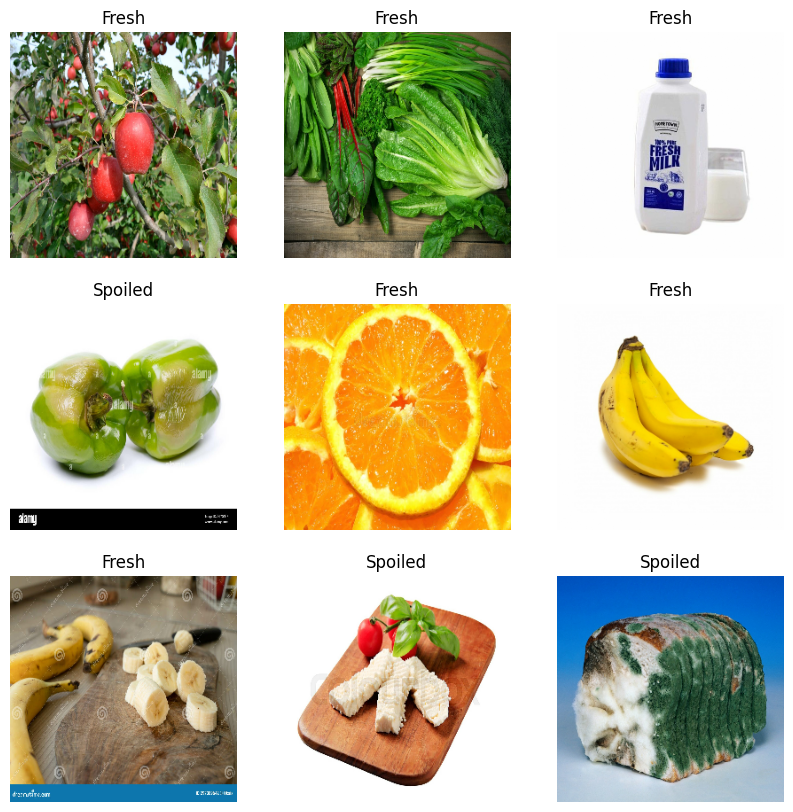

Train class distribution: [1033 1192]
Validation class distribution: [259 299]


2025-10-02 06:28:35.858282: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [2]:
import tensorflow as tf
import pathlib, random, numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------
# 1. Gather all valid images
# ------------------------------
dataset_dir = pathlib.Path("./dataset")
fresh_files = list(dataset_dir.glob("fresh/*.jpg")) + list(dataset_dir.glob("fresh/*.jpeg"))
spoiled_files = list(dataset_dir.glob("spoiled/*.jpg")) + list(dataset_dir.glob("spoiled/*.jpeg"))

def verify_image(path):
    try:
        img = Image.open(path)
        img.verify()  # check if image is corrupted
        return True
    except:
        print("Skipping invalid image:", path)
        return False

fresh_files = [str(f) for f in fresh_files if verify_image(f)]
spoiled_files = [str(f) for f in spoiled_files if verify_image(f)]

random.seed(42)
random.shuffle(fresh_files)
random.shuffle(spoiled_files)

# 80/20 split
train_fresh = fresh_files[:int(0.8*len(fresh_files))]
val_fresh   = fresh_files[int(0.8*len(fresh_files)):]
train_spoiled = spoiled_files[:int(0.8*len(spoiled_files))]
val_spoiled   = spoiled_files[int(0.8*len(spoiled_files)):]

train_files = train_fresh + train_spoiled
train_labels = [0]*len(train_fresh) + [1]*len(train_spoiled)

val_files = val_fresh + val_spoiled
val_labels = [0]*len(val_fresh) + [1]*len(val_spoiled)

# shuffle
train_data = list(zip(train_files, train_labels))
random.shuffle(train_data)
train_files, train_labels = zip(*train_data)

# ------------------------------
# 2. Decode images safely
# ------------------------------
def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)  # safer than decode_jpeg
    img = tf.image.resize(img, [256,256])
    img = tf.cast(img, tf.float32)/255.0
    img.set_shape([256,256,3])
    return img, label

# ------------------------------
# 3. Create Dataset
# ------------------------------
train_ds = tf.data.Dataset.from_tensor_slices((list(train_files), list(train_labels)))
train_ds = train_ds.map(decode_img, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((list(val_files), list(val_labels)))
val_ds = val_ds.map(decode_img, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# ------------------------------
# 4. Display samples
# ------------------------------
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title("Fresh" if labels[i]==0 else "Spoiled")
        plt.axis("off")
    plt.show()

# ------------------------------
# 5. Class distribution
# ------------------------------
train_labels_arr = np.array(train_labels)
val_labels_arr = np.array(val_labels)
print("Train class distribution:", np.bincount(train_labels_arr))
print("Validation class distribution:", np.bincount(val_labels_arr))


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
import numpy as np

# ------------------------------
# Class weights
# ------------------------------
train_labels_arr = np.array(train_labels)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_arr),
    y=train_labels_arr
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)


Class weights: {0: 1.0769603097773475, 1: 0.9333053691275168}


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
model = Sequential([
    # Data augmentation as first layer
    layers.RandomFlip("horizontal", input_shape=(256,256,3)),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    
    # CNN layers
    Conv2D(32,(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
# compile the model
#  Optimizer with learning rate

optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',  # because one-hot encoded labels
    metrics=['accuracy']
)

# call backs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # reduce LR by half
    patience=5,          # wait 3 epochs
    min_lr=1e-6,
    verbose=1
)
    

/opt/conda/lib/python3.10/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,  # already computed
    callbacks=[early_stop, reduce_lr]
)
model.save('my_binary_class_model.h5')

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.5712 - loss: 1.0082 - val_accuracy: 0.6308 - val_loss: 0.8569 - learning_rate: 1.0000e-04
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.6391 - loss: 0.7993 - val_accuracy: 0.6308 - val_loss: 0.7800 - learning_rate: 1.0000e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.6476 - loss: 0.7419 - val_accuracy: 0.6487 - val_loss: 0.7386 - learning_rate: 1.0000e-04
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.6575 - loss: 0.7131 - val_accuracy: 0.6631 - val_loss: 0.7063 - learning_rate: 1.0000e-04
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.6638 - loss: 0.6871 - val_accuracy: 0.6792 - val_loss: 0.6822 - learning_rate: 1.0000e-04
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.6719 - loss: 0.6723 - val_accuracy: 0.6935 - val_loss: 0.6669 - learning_rate: 1.0000e-04
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.6746 

In [4]:
!pip install flask
!pip install requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [flask]


18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 695ms/step - accuracy: 0.7527 - loss: 0.5515
Test loss: 0.5515  |  Test accuracy: 0.7527
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step


2025-10-01 07:10:00.029189: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


y_true shape: (558,)  y_pred shape: (558,)
Unique preds: (array([0, 1]), array([279, 279]))


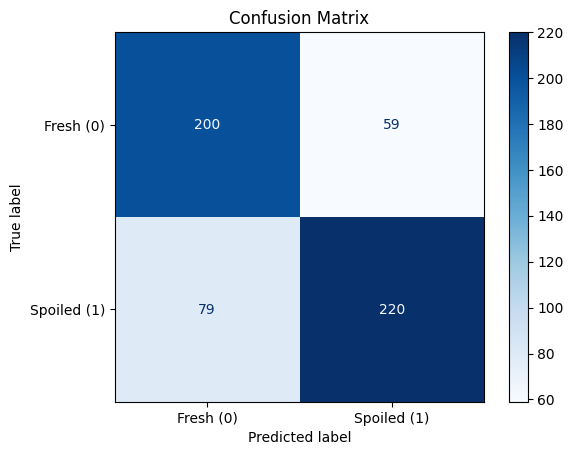


Classification Report:

              precision    recall  f1-score   support

       Fresh       0.72      0.77      0.74       259
     Spoiled       0.79      0.74      0.76       299

    accuracy                           0.75       558
   macro avg       0.75      0.75      0.75       558
weighted avg       0.76      0.75      0.75       558

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step


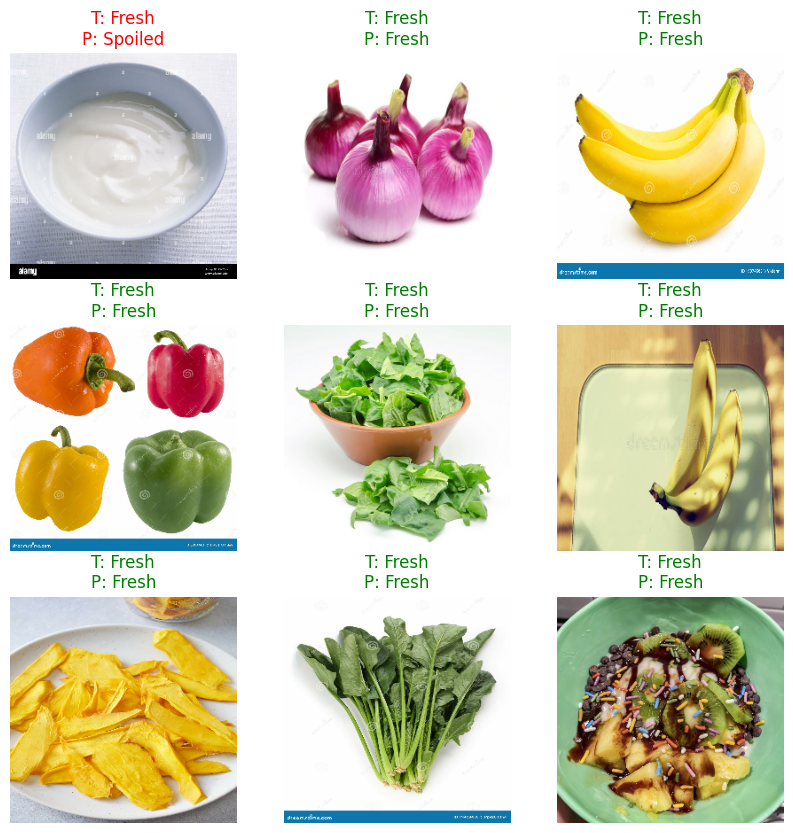

In [12]:
# --- Correct evaluation for a sigmoid single-output binary model ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# load model
model = load_model("my_binary_class_model.h5")

# use val_ds created earlier as test dataset
test_ds = val_ds  # you already had val_ds

# 1) Evaluate overall
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

# 2) Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)            # shape (batch, 1)
    preds = preds.squeeze()                  # shape (batch,)
    preds = (preds > 0.5).astype(int)        # threshold -> 0 or 1
    y_true.extend(labels.numpy().astype(int))# labels as ints
    y_pred.extend(preds.astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# sanity check
print("y_true shape:", y_true.shape, " y_pred shape:", y_pred.shape)
print("Unique preds:", np.unique(y_pred, return_counts=True))

# 3) Confusion matrix & classification report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fresh (0)", "Spoiled (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Fresh", "Spoiled"]))

# 4) Show a few samples with predictions
plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):  # one batch
    preds = model.predict(images).squeeze()
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        true_label = "Fresh" if int(labels[i].numpy()) == 0 else "Spoiled"
        pred_label = "Fresh" if preds[i] <= 0.5 else "Spoiled"
        color = "green" if true_label == pred_label else "red"
        plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
        plt.axis("off")
plt.show()


In [7]:
preds = model.predict(val_ds)
print("Predicted classes count:", np.bincount(np.argmax(preds, axis=1)))


18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 696ms/step
Predicted classes count: [558]


In [9]:
print(val_labels)


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [7]:
#---------------------To check with other images----------------------#

from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
from IPython.display import display
import ipywidgets as widgets
import io

# Load model
model = load_model("my_binary_class_model.h5")

# Create upload widget
upload = widgets.FileUpload(
    accept='image/*',  # accept images only
    multiple=False     # single image at a time
)
display(upload)

def predict_uploaded_image(uploaded):
    if len(uploaded.value) == 0:
        print("No image uploaded!")
        return
    
    # Get the first uploaded file
    file_info = uploaded.value[0]  # tuple format
    content = file_info['content'] if 'content' in file_info else file_info
    img = Image.open(io.BytesIO(content)).resize((256, 256))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    pred = model.predict(img_array)
    label = "Fresh" if pred[0][0] < 0.5 else "Spoiled"
    display(img)
    print(f"Prediction: {label}, Probability: {pred[0][0]:.4f}")

# Button to trigger prediction
button = widgets.Button(description="Predict")
output = widgets.Output()

def on_button_click(b):
    with output:
        output.clear_output()
        predict_uploaded_image(upload)

button.on_click(on_button_click)
display(button, output)


FileUpload(value=(), accept='image/*', description='Upload')

Button(description='Predict', style=ButtonStyle())

Output()

2025-10-02 06:39:52.464849: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 601ms/step
Total misclassified images: 138


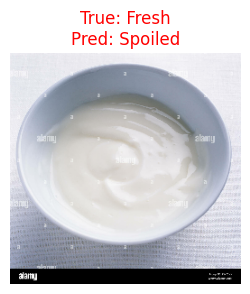

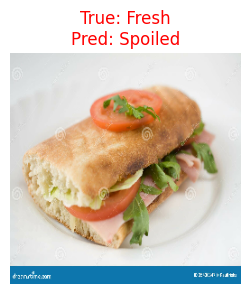

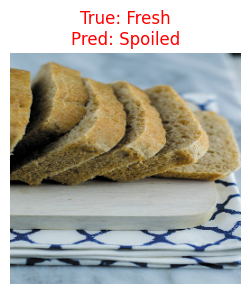

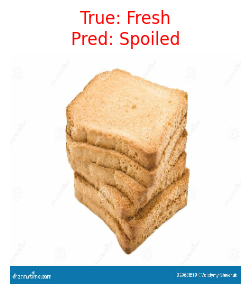

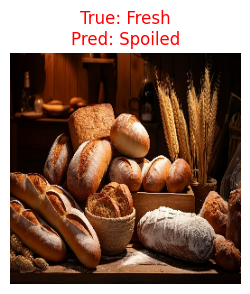

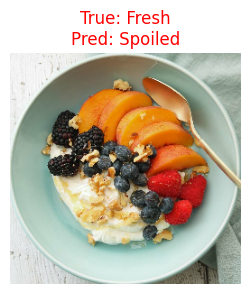

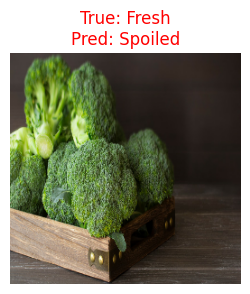

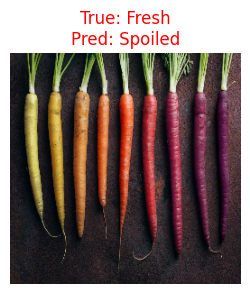

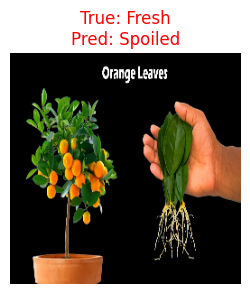

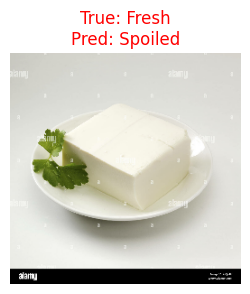

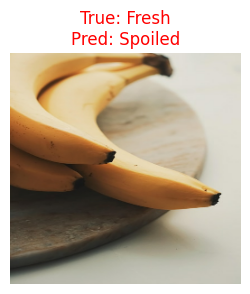

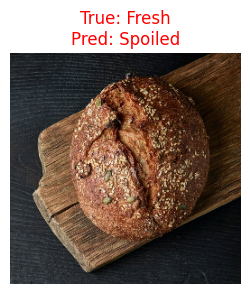

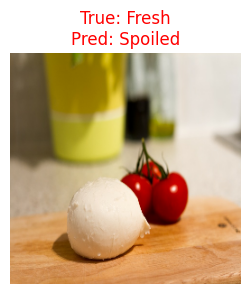

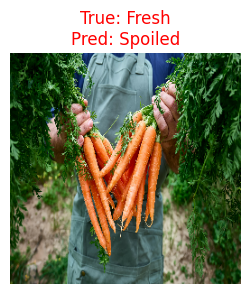

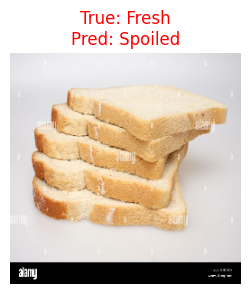

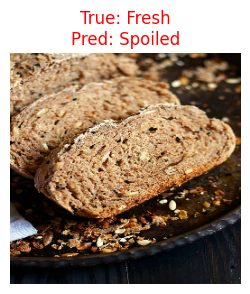

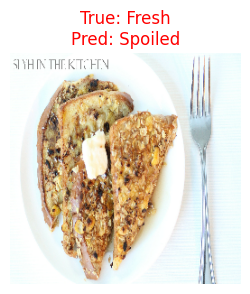

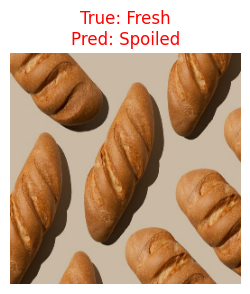

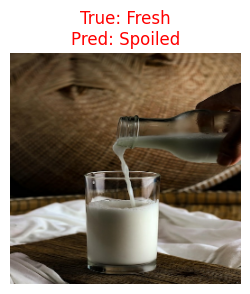

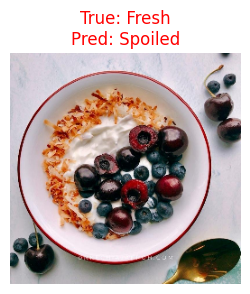

In [6]:
#---------------- To Display failed cases--------------------------------

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
class_names = ["Fresh", "Spoiled"]
# Load model
model = load_model("my_binary_class_model.h5")
images = []
labels = []
for img_batch, label_batch in val_ds:   # ✅ using val_ds here
    images.append(img_batch.numpy())
    labels.append(label_batch.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

pred_probs = model.predict(images)
pred_labels = (pred_probs > 0.5).astype(int).reshape(-1)

misclassified_idx = np.where(pred_labels != labels)[0]

print(f"Total misclassified images: {len(misclassified_idx)}")

for i, idx in enumerate(misclassified_idx[:20]):
    plt.figure(figsize=(3,3))
    plt.imshow((images[idx]*255).astype("uint8"))
    true_label = class_names[labels[idx]]
    pred_label = class_names[pred_labels[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}", color="red")
    plt.axis("off")
    plt.show()


model.summary()

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,233,987 (50.48 MB)

 Trainable params: 13,233,985 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [3]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 115.7 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 132.4 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.6 which is incompatible.
ydata-profiling 4.16.1 requires numpy<2.2,>=1.16.0, but you have numpy 2.2.6 which is incompatible.


In [30]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load your trained model
model = tf.keras.models.load_model("my_binary_class_model.h5")

# Call model once to initialize (important for Sequential models)
dummy_input = np.random.rand(1,256,256,3).astype(np.float32)
_ = model(dummy_input)

last_conv_layer_name = "conv2d_3"
class_names = ["Fresh", "Spoiled"]  # adjust if needed

# Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions

# Overlay heatmap on image
def apply_heatmap(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return superimposed_img

# Upload widget
uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

output = widgets.Output()
display(uploader, output)  # show both upload button and output

def on_upload_change(change):
    with output:
        output.clear_output(wait=True)
        
        if uploader.value:
            # Check if it's a tuple or dict
            file_data = uploader.value
            if isinstance(file_data, tuple):
                uploaded_file = file_data[0]
            else:  # dict (Colab)
                uploaded_file = next(iter(file_data.values()))
            
            # Open image
            img = Image.open(io.BytesIO(uploaded_file['content'])).convert("RGB")
            img_resized = img.resize((256,256))
            img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)
            
            # Grad-CAM
            heatmap, preds = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
            pred_label = int(preds[0] > 0.5)
            label = class_names[pred_label]
            confidence = float(preds[0])
            
            # Convert to cv2 format
            img_cv = cv2.cvtColor(np.array(img_resized), cv2.COLOR_RGB2BGR)
            gradcam_img = apply_heatmap(img_cv, heatmap)
            
            # Plot results
            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1)
            plt.imshow(img_resized)
            plt.title("Original")
            plt.axis("off")
            
            plt.subplot(1,2,2)
            plt.imshow(cv2.cvtColor(gradcam_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Grad-CAM → {label} ({confidence:.2f})")
            plt.axis("off")
            plt.show()



FileUpload(value=(), accept='image/*', description='Upload')

FileUpload(value=(), accept='image/*', description='Upload')

Output()

In [45]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------
# 1️⃣ Load your trained model
# ------------------------------
model = tf.keras.models.load_model("my_binary_class_model.h5")

# Call model once to initialize (important for Sequential models)
dummy_input = np.random.rand(1, 256, 256, 3).astype(np.float32)
_ = model(dummy_input)

# Automatically find last Conv2D layer
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break
print("Using last Conv2D layer for Grad-CAM:", last_conv_layer_name)

# Class names
class_names = ["Fresh", "Spoiled"]

# ------------------------------
# 2️⃣ Grad-CAM function
# ------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input, 
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
        
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy(), predictions

# ------------------------------
# 3️⃣ Overlay heatmap on image
# ------------------------------
def apply_heatmap(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return superimposed_img

# ------------------------------
# 4️⃣ Upload widget
# ------------------------------
uploader = widgets.FileUpload(accept='image/*', multiple=False)
output = widgets.Output()
display(uploader, output)

def on_upload_change(change):
    with output:
        output.clear_output(wait=True)
        if uploader.value:
            uploaded_file = next(iter(uploader.value.values()))
            img = Image.open(io.BytesIO(uploaded_file['content'])).convert("RGB")
            img_resized = img.resize((256,256))
            img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0).astype(np.float32)
            
            # Grad-CAM
            heatmap, preds = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
            pred_label = int(preds[0] > 0.5)
            label = class_names[pred_label]
            confidence = float(preds[0])
            
            img_cv = cv2.cvtColor(np.array(img_resized), cv2.COLOR_RGB2BGR)
            gradcam_img = apply_heatmap(img_cv, heatmap)
            
            # Display
            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1)
            plt.imshow(img_resized)
            plt.title("Original")
            plt.axis("off")
            
            plt.subplot(1,2,2)
            plt.imshow(cv2.cvtColor(gradcam_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Grad-CAM → {label} ({confidence:.2f})")
            plt.axis("off")
            plt.show()

uploader.observe(on_upload_change, names='value')


Using last Conv2D layer for Grad-CAM: conv2d_3


FileUpload(value=(), accept='image/*', description='Upload')

Output()

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, 0]  # binary classification
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [23]:
def display_gradcam(img, model, last_conv_layer_name="conv2d_3"):
    import cv2
    img_array = np.expand_dims(img, axis=0)  # add batch dim
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    
    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + np.uint8(img*255)
    
    plt.figure(figsize=(6,6))
    plt.imshow(superimposed_img.astype(np.uint8))
    plt.axis("off")
    plt.show()
